# Append street network data from OSM

In [1]:
import pandas as pd
import geopandas as gp
import os

In [7]:
# run append_osmnx.py to download and append OSM street network data

In [6]:
# ls_df = []
# read_folder = './sample_data/snapped'
# for name in os.listdir(read_folder):
#     if name != '.DS_Store':
#         read_path = os.path.join(read_folder, name)
#         if os.path.isfile(read_path):
#             df = pd.read_csv(read_path)
#             ls_df.append(df) 
snapped = pd.read_csv('/home/kieran/Documents/Python/sunny_day_SVI/city7sample/snapped/1032717330_snapped.csv')
#snapped = pd.concat(ls_df).drop(columns=['Unnamed: 0']).reset_index(drop=True)
snapped.drop(columns=['Unnamed: 0']).reset_index(drop=True)
snapped.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35491 entries, 0 to 35490
Data columns (total 43 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0.1     35491 non-null  int64  
 1   pt_idx           35491 non-null  int64  
 2   line_i           35491 non-null  float64
 3   index            35491 non-null  int64  
 4   u                35491 non-null  int64  
 5   v                35491 non-null  int64  
 6   key              35491 non-null  int64  
 7   osmid            35491 non-null  object 
 8   highway          35491 non-null  object 
 9   lanes            31313 non-null  float64
 10  maxspeed         33045 non-null  object 
 11  name             34323 non-null  object 
 12  oneway           35491 non-null  bool   
 13  reversed         35491 non-null  object 
 14  length           35491 non-null  float64
 15  from             35491 non-null  int64  
 16  to               35491 non-null  int64  
 17  ref         

## Calculate type_highway

In [7]:
snapped['highway'].value_counts()

highway
residential                  12192
primary                       5987
secondary                     4708
service                       4426
trunk                         2855
footway                       2702
tertiary                      2041
trunk_link                     239
['footway', 'steps']           193
cycleway                        63
steps                           33
pedestrian                      25
['pedestrian', 'footway']       17
living_street                   10
Name: count, dtype: int64

In [8]:
import ast

def str_to_list(row):
    highway = row['highway']
    if '[' in highway:
        ls = ast.literal_eval(highway)
        return ls
    else:
        return [highway]

In [9]:
snapped['ls_highway'] = snapped.apply(lambda row: str_to_list(row), axis=1)
snapped.head()

,Unnamed: 0.1,pt_idx,line_i,index,u,v,key,osmid,highway,lanes,...,lat,lon,timezone,utc-offset,datetime-local,snap_dist,l_geom_wkt,og_pt_wkt,snp_pt_wkt,ls_highway
0,0,0,13611.0,13611,11806410296,11806410306,0,1300307252,trunk,5.0,...,-34.600614,-58.382024,America/Argentina/Buenos_Aires,-10800.0,2024-08-23 16:02:18.199000-03:00,0.711176,"LINESTRING (373273.198727 6170404.033848, 3732...",POINT (373273.972012 6170377.897475),POINT (373274.682041 6170377.937834),[trunk]
1,1,1,661.0,661,178681855,195898445,0,533174415,residential,2.0,...,-34.605458,-58.400783,America/Argentina/Buenos_Aires,-10800.0,2024-08-24 10:04:32.190000-03:00,0.694990,"LINESTRING (371554.967491 6169903.236358, 3715...",POINT (371561.150646 6169816.989919),POINT (371561.843435 6169817.045186),[residential]
2,2,2,3178.0,3178,232201355,11955985038,0,103757458,secondary,5.0,...,-34.597187,-58.393251,America/Argentina/Buenos_Aires,-10800.0,2024-08-22 16:16:02.536000-03:00,4.404685,"LINESTRING (372243.978499 6170739.52412, 37222...",POINT (372239.113893 6170743.745445),POINT (372243.495223 6170744.19843),[secondary]
3,3,4,11183.0,11183,6672693023,6672693032,0,71179557,residential,2.0,...,-34.597510,-58.384234,America/Argentina/Buenos_Aires,-10800.0,2024-08-24 16:24:51.999000-03:00,9.352078,"LINESTRING (373080.322908 6170664.616933, 3730...",POINT (373066.573234 6170719.379804),POINT (373075.895706 6170720.123366),[residential]
4,4,5,4892.0,4892,1135635735,11806410298,0,25964724,tertiary,4.0,...,-34.601232,-58.382362,America/Argentina/Buenos_Aires,-10800.0,2016-11-12 13:01:42-03:00,2.502724,"LINESTRING (373237.620011 6170359.233305, 3732...",POINT (373243.919883 6170308.915973),POINT (373241.424229 6170308.727992),[tertiary]


In [10]:
snapped['highway2'] = snapped['ls_highway'].apply(lambda ls: ls[0])

In [11]:
snapped['highway2'].value_counts()[:20]

highway2
residential      12192
primary           5987
secondary         4708
service           4426
footway           2895
trunk             2855
tertiary          2041
trunk_link         239
cycleway            63
pedestrian          42
steps               33
living_street       10
Name: count, dtype: int64

<Axes: ylabel='proportion'>

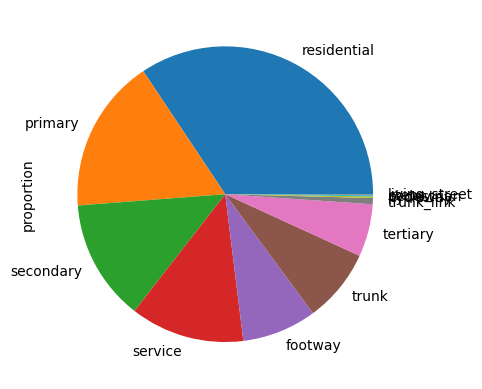

In [12]:
snapped['highway2'].value_counts(normalize=True).plot(kind='pie')

In [13]:
snapped['highway2'].unique().tolist()

['trunk',
 'residential',
 'secondary',
 'tertiary',
 'footway',
 'service',
 'primary',
 'cycleway',
 'trunk_link',
 'steps',
 'living_street',
 'pedestrian']

In [14]:
d = {
    'residential': 'drive',
    'footway': 'walk',
    'motorway': 'drive', 
    'cycleway': 'cycle',
    'corridor': 'walk',
    'tertiary': 'drive',
    'primary': 'drive',
    'trunk': 'drive',
    'pedestrian': 'walk',
    'secondary': 'drive',
    'service': 'drive',
    'path': 'walk/cycle',
    'unclassified': 'drive',
    'trunk_link': 'drive',
    'primary_link': 'drive',
    'motorway_link': 'drive',
    'busway': 'drive',
    'tertiary_link': 'drive',
    'living_street': 'walk/cycle',
    'steps': 'walk',
    'bridleway': 'others',
    'secondary_link': 'drive',
    'track': 'others',
    'bus_stop': 'drive',
    'crossing': 'walk',
    'elevator': 'others',
    'razed': 'others',
    'busway': 'drive',
    'road': 'drive',
    'rest_area': 'drive',
    'bus_guideway': 'drive'
}

In [15]:
[a for a in snapped['highway2'].unique().tolist() if a not in list(d.keys())]

[]

In [16]:
snapped['type_highway'] = snapped['highway2'].apply(lambda x: d[x])

In [17]:
snapped['type_highway'].value_counts()

type_highway
drive         32448
walk           2970
cycle            63
walk/cycle       10
Name: count, dtype: int64

<Axes: ylabel='proportion'>

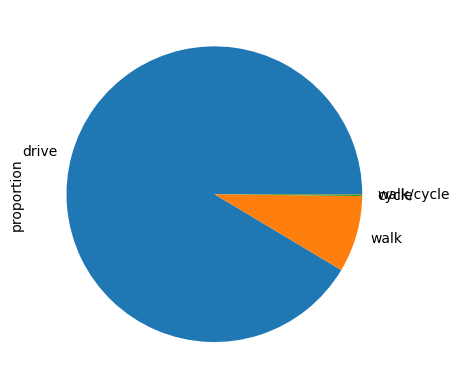

In [18]:
snapped['type_highway'].value_counts(normalize=True).plot(kind='pie')

In [19]:
snapped

,Unnamed: 0.1,pt_idx,line_i,index,u,v,key,osmid,highway,lanes,...,timezone,utc-offset,datetime-local,snap_dist,l_geom_wkt,og_pt_wkt,snp_pt_wkt,ls_highway,highway2,type_highway
0,0,0,13611.0,13611,11806410296,11806410306,0,1300307252,trunk,5.0,...,America/Argentina/Buenos_Aires,-10800.0,2024-08-23 16:02:18.199000-03:00,0.711176,"LINESTRING (373273.198727 6170404.033848, 3732...",POINT (373273.972012 6170377.897475),POINT (373274.682041 6170377.937834),[trunk],trunk,drive
1,1,1,661.0,661,178681855,195898445,0,533174415,residential,2.0,...,America/Argentina/Buenos_Aires,-10800.0,2024-08-24 10:04:32.190000-03:00,0.694990,"LINESTRING (371554.967491 6169903.236358, 3715...",POINT (371561.150646 6169816.989919),POINT (371561.843435 6169817.045186),[residential],residential,drive
2,2,2,3178.0,3178,232201355,11955985038,0,103757458,secondary,5.0,...,America/Argentina/Buenos_Aires,-10800.0,2024-08-22 16:16:02.536000-03:00,4.404685,"LINESTRING (372243.978499 6170739.52412, 37222...",POINT (372239.113893 6170743.745445),POINT (372243.495223 6170744.19843),[secondary],secondary,drive
3,3,4,11183.0,11183,6672693023,6672693032,0,71179557,residential,2.0,...,America/Argentina/Buenos_Aires,-10800.0,2024-08-24 16:24:51.999000-03:00,9.352078,"LINESTRING (373080.322908 6170664.616933, 3730...",POINT (373066.573234 6170719.379804),POINT (373075.895706 6170720.123366),[residential],residential,drive
4,4,5,4892.0,4892,1135635735,11806410298,0,25964724,tertiary,4.0,...,America/Argentina/Buenos_Aires,-10800.0,2016-11-12 13:01:42-03:00,2.502724,"LINESTRING (373237.620011 6170359.233305, 3732...",POINT (373243.919883 6170308.915973),POINT (373241.424229 6170308.727992),[tertiary],tertiary,drive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35486,35486,43493,2435.0,2435,195898424,232065108,0,421717866,service,2.0,...,America/Argentina/Buenos_Aires,-10800.0,2024-08-24 08:28:15.590000-03:00,9.833358,"LINESTRING (371966.232446 6169926.908134, 3719...",POINT (372019.805568 6169915.42351),POINT (372019.379383 6169925.247627),[service],service,drive
35487,35487,43495,1618.0,1618,195571467,195722778,0,537041235,primary,3.0,...,America/Argentina/Buenos_Aires,-10800.0,2024-08-24 09:50:07.195000-03:00,2.361555,"LINESTRING (371979.000195 6169376.290292, 3718...",POINT (371905.395418 6169366.297979),POINT (371905.152295 6169368.646986),[primary],primary,drive
35488,35488,43496,1092.0,1092,192906559,195645552,0,533153703,residential,2.0,...,America/Argentina/Buenos_Aires,-10800.0,2024-08-24 16:23:34-03:00,4.577324,"LINESTRING (372946.939467 6170644.617109, 3730...",POINT (372964.313129 6170641.566997),POINT (372963.907605 6170646.126322),[residential],residential,drive
35489,35489,43498,4068.0,4068,315918084,6677085356,0,28733739,footway,6.0,...,America/Argentina/Buenos_Aires,-10800.0,2024-08-24 08:17:26.997000-03:00,3.843600,"LINESTRING (372747.075524 6169388.755404, 3727...",POINT (372741.304626 6169398.408415),POINT (372738.878298 6169395.427443),[footway],footway,walk


In [20]:
snapped.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35491 entries, 0 to 35490
Data columns (total 46 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0.1     35491 non-null  int64  
 1   pt_idx           35491 non-null  int64  
 2   line_i           35491 non-null  float64
 3   index            35491 non-null  int64  
 4   u                35491 non-null  int64  
 5   v                35491 non-null  int64  
 6   key              35491 non-null  int64  
 7   osmid            35491 non-null  object 
 8   highway          35491 non-null  object 
 9   lanes            31313 non-null  float64
 10  maxspeed         33045 non-null  object 
 11  name             34323 non-null  object 
 12  oneway           35491 non-null  bool   
 13  reversed         35491 non-null  object 
 14  length           35491 non-null  float64
 15  from             35491 non-null  int64  
 16  to               35491 non-null  int64  
 17  ref         

In [ ]:
#osm = pd.read_csv('./sample_data/02_metadata_common_attributes.csv')[['uuid', 'source', 'orig_id']]

In [ ]:
#osm = osm.merge(snapped.drop(columns=['source', 'orig_id']), on='uuid', how='left')
#osm.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2319 entries, 0 to 2318
Data columns (total 48 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   uuid          2319 non-null   object 
 1   source        2319 non-null   object 
 2   orig_id       2319 non-null   int64  
 3   pt_idx        2300 non-null   float64
 4   line_i        2300 non-null   float64
 5   index         2300 non-null   float64
 6   u             2300 non-null   float64
 7   v             2300 non-null   float64
 8   key           2300 non-null   float64
 9   osmid         2300 non-null   object 
 10  lanes         968 non-null    object 
 11  name          1779 non-null   object 
 12  highway       2300 non-null   object 
 13  maxspeed      1646 non-null   object 
 14  oneway        2300 non-null   object 
 15  length        2300 non-null   float64
 16  from          2300 non-null   float64
 17  to            2300 non-null   float64
 18  road_width    1480 non-null 

In [21]:
osm = snapped

In [23]:
cols = ['id',
 'snap_dist',
 'u',
 'v',
 'key',
 'osmid',
 'oneway',
 'lanes',
 'name',
 'highway',
 'type_highway',
 'maxspeed',
 'junction',
 'length',
 'from',
 'to',
 'ref',
 'tunnel',
 'bridge',
 'service',
 'access',
 'road_width']
osm = osm[cols]

In [24]:
osm.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35491 entries, 0 to 35490
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            35491 non-null  int64  
 1   snap_dist     35491 non-null  float64
 2   u             35491 non-null  int64  
 3   v             35491 non-null  int64  
 4   key           35491 non-null  int64  
 5   osmid         35491 non-null  object 
 6   oneway        35491 non-null  bool   
 7   lanes         31313 non-null  float64
 8   name          34323 non-null  object 
 9   highway       35491 non-null  object 
 10  type_highway  35491 non-null  object 
 11  maxspeed      33045 non-null  object 
 12  junction      0 non-null      float64
 13  length        35491 non-null  float64
 14  from          35491 non-null  int64  
 15  to            35491 non-null  int64  
 16  ref           0 non-null      float64
 17  tunnel        616 non-null    object 
 18  bridge        0 non-null  

In [25]:
osm.to_csv('/home/kieran/Documents/Python/sunny_day_SVI/city7sample/buenos_aires_osm.csv', index=False)